# Question 1: TF-IDF Vectorization
# Task: Convert the text data into a TF-IDF matrix and display the features.

In [2]:
documents = [
    "I love machine learning and NLP.",
    "TF-IDF is a popular method in text mining.",
    "Natural Language Processing is fascinating.",
    "I love learning new things in NLP."
]

# Solution

In [1]:
!pip show scikit-learn
!pip install --upgrade scikit-learn

Name: scikit-learn
Version: 1.0.2
Summary: A set of python modules for machine learning and data mining
Home-page: http://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: c:\anaconda\envs\dataai\lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: eli5, PDPbox, shap


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

documents = [
    "I love machine learning and NLP.",
    "TF-IDF is a popular method in text mining.",
    "Natural Language Processing is fascinating.",
    "I love learning new things in NLP."
]

# Initialize and fit the vectorizer
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

# Display features and matrix
features = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=features)
print(df_tfidf)


        and  fascinating       idf        in        is  language  learning  \
0  0.508672     0.000000  0.000000  0.000000  0.000000  0.000000  0.401043   
1  0.000000     0.000000  0.371565  0.292946  0.292946  0.000000  0.000000   
2  0.000000     0.465162  0.000000  0.000000  0.366739  0.465162  0.000000   
3  0.000000     0.000000  0.000000  0.372225  0.000000  0.000000  0.372225   

       love   machine    method    mining   natural      new       nlp  \
0  0.401043  0.508672  0.000000  0.000000  0.000000  0.00000  0.401043   
1  0.000000  0.000000  0.371565  0.371565  0.000000  0.00000  0.000000   
2  0.000000  0.000000  0.000000  0.000000  0.465162  0.00000  0.000000   
3  0.372225  0.000000  0.000000  0.000000  0.000000  0.47212  0.372225   

    popular  processing      text        tf   things  
0  0.000000    0.000000  0.000000  0.000000  0.00000  
1  0.371565    0.000000  0.371565  0.371565  0.00000  
2  0.000000    0.465162  0.000000  0.000000  0.00000  
3  0.000000    0.0

# Question 2: CountVectorizer
# Task: Use CountVectorizer to find word frequency.

In [4]:
texts = [
    "ChatGPT is an LLM model.",
    "ChatGPT is useful for NLP tasks.",
    "NLP involves working with language."
]


# Solution

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

texts = [
    "ChatGPT is an LLM model.",
    "ChatGPT is useful for NLP tasks.",
    "NLP involves working with language."
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

word_freq = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out()).sum().sort_values(ascending=False)
print(word_freq)

nlp         2
is          2
chatgpt     2
working     1
with        1
useful      1
tasks       1
model       1
llm         1
language    1
involves    1
for         1
an          1
dtype: int64


# Question 3: Topic Modeling using LDA
# Task: Apply Latent Dirichlet Allocation (LDA) to find topics from the text.

In [6]:
documents = [
    "Data science is an interdisciplinary field.",
    "Artificial intelligence and machine learning are part of data science.",
    "Natural language processing helps computers understand text.",
    "Deep learning is useful in image and text processing."
]


# Solution

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

documents = [
    "Data science is an interdisciplinary field.",
    "Artificial intelligence and machine learning are part of data science.",
    "Natural language processing helps computers understand text.",
    "Deep learning is useful in image and text processing."
]

# 1. Vectorize text (remove English stop words)
vectorizer = CountVectorizer(stop_words='english')
doc_term_matrix = vectorizer.fit_transform(documents)

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

# 2. Apply LDA
# n_components is the number of topics
lda_model = LatentDirichletAllocation(n_components=2, random_state=42)
lda_model.fit(doc_term_matrix)

# Display topics
words = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda_model.components_):
    print(f"Topic #{idx + 1}:")
    print([words[i] for i in topic.argsort()[-5:]])

Topic #1:
['intelligence', 'artificial', 'learning', 'data', 'science']
Topic #2:
['helps', 'understand', 'language', 'processing', 'text']


# Question 4: Sentiment Analysis using VADER
# Task: Analyze sentiment of given text reviews.

In [8]:
sentences = [
    "I love the new feature, it's amazing!",
    "This update is terrible and frustrating.",
    "The service was okay, not the best.",
    "I’m so happy with the experience!",
    "Very disappointed. Will not recommend."
]


# Solution

In [14]:
# Sentiment Analysis using VADER
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer


sentences = [
    "I love the new feature, it's amazing!",
    "This update is terrible and frustrating.",
    "The service was okay, not the best.",
    "I’m so happy with the experience!",
    "Very disappointed. Will not recommend."
]

analyzer = SentimentIntensityAnalyzer()
for sentence in sentences:
    vs = analyzer.polarity_scores(sentence)
    print(f"{sentence} : --->{score}")


I love the new feature, it's amazing! : --->{'neg': 0.647, 'neu': 0.353, 'pos': 0.0, 'compound': -0.6708}
This update is terrible and frustrating. : --->{'neg': 0.647, 'neu': 0.353, 'pos': 0.0, 'compound': -0.6708}
The service was okay, not the best. : --->{'neg': 0.647, 'neu': 0.353, 'pos': 0.0, 'compound': -0.6708}
I’m so happy with the experience! : --->{'neg': 0.647, 'neu': 0.353, 'pos': 0.0, 'compound': -0.6708}
Very disappointed. Will not recommend. : --->{'neg': 0.647, 'neu': 0.353, 'pos': 0.0, 'compound': -0.6708}


[nltk_data] Downloading package vader_lexicon to C:\Users\SURYA
[nltk_data]     MURUGANANTHAM\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Question 5: Generate a Word Cloud
# Task: Generate a word cloud from the input text.

In [ ]:
text = """
Natural language processing enables computers to understand and respond to human language.
Applications include sentiment analysis, machine translation, and topic modeling.
"""


# solution

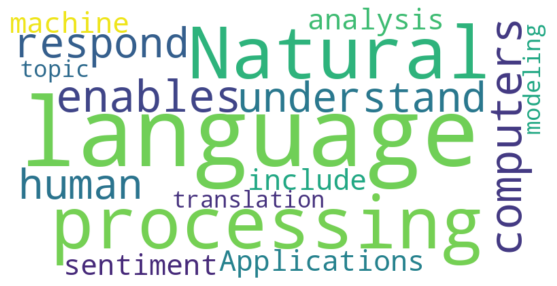

In [16]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Input text
text = """ Natural language processing enables computers to understand and respond to human language. 
Applications include sentiment analysis, machine translation, and topic modeling. """

# Create the word cloud object
# You can find documentation on customization at the [WordCloud GitHub](https://github.com)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud using [Matplotlib](https://matplotlib.org)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove axes
plt.show()
